In [ ]:
# pandas settings for visualization
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x) #forces 2 decimals
pd.set_option('display.max_rows', 1000) #amount of rows displayed before ...

In [ ]:
# orders.csv
url = "https://drive.google.com/file/d/1Vu0q91qZw6lqhIqbjoXYvYAQTmVHh6uZ/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)

# orderlines.csv
url = "https://drive.google.com/file/d/1FYhN_2AzTBFuWcfHaRuKcuCE6CWXsWtG/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines = pd.read_csv(path)

# brands.csv
url = "https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

# products.csv
url = "https://drive.google.com/file/d/1afxwDXfl-7cQ_qLwyDitfcCx3u7WMvkU/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

# Creating copies of DataFrames for data manipulatrion

In [ ]:
orders_df = orders.copy()
orderlines_df = orderlines.copy()
brands_df = brands.copy()
products_df = products.copy()

# Checking for duplicates

In [ ]:
orders_df.duplicated().sum()

np.int64(0)

In [ ]:
orderlines_df.duplicated().sum()

np.int64(0)

In [ ]:
brands_df.duplicated().sum()

np.int64(0)

In [ ]:
products_df.duplicated().sum()

np.int64(8746)

# Checking the DataFrames

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB




*   total_paid has 5 missing values
*   created_date should become datetime datatype





In [ ]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                293983 non-null  int64 
 1   id_order          293983 non-null  int64 
 2   product_id        293983 non-null  int64 
 3   product_quantity  293983 non-null  int64 
 4   sku               293983 non-null  object
 5   unit_price        293983 non-null  object
 6   date              293983 non-null  object
dtypes: int64(4), object(3)
memory usage: 15.7+ MB




*   date should be a datetime datatype
*   unit_price should be a float datatype



In [ ]:
brands_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


- price should be a float datatype
- promo_price should be a float datatype

# Missing values

## Orders

In [ ]:
orders_df['total_paid'].isna().value_counts(normalize=True)

,proportion
total_paid,
False,1.00
True,0.00


### Deleting those missing values

In [ ]:
orders_df = orders_df.dropna(axis=0)

#since they represent a tiny % of the total

##Orderlines

In [ ]:
orderlines_df.isna().value_counts(normalize=True)

#there are no missing values

,,,,,,,proportion
id,id_order,product_id,product_quantity,sku,unit_price,date,
False,False,False,False,False,False,False,1.00


##Brands

In [ ]:
brands_df.isna().value_counts(normalize=True)

#there are no missing values

,,proportion
short,long,
False,False,1.00


##Products

###Clearing duplicates

In [ ]:
products_df.duplicated().sum()

np.int64(8746)

In [ ]:
#delete duplicates
products_df = products_df.drop_duplicates()

In [ ]:
#duplicate SKU

products_df = products_df[~((products_df['sku'] == 'APP1197') & (products_df['price'].isna()))]

In [ ]:
# to confirm the above

print(products_df['sku'].duplicated().sum())

0


###Desc with missing values

In [ ]:
#replace empty desc with "No description"

products_df['desc'] = products_df['desc'].fillna('No description')

###Fixing price

In [ ]:
products_df.price.isna().sum()
print(f"The missing values in price are {(products_df.price.isna().value_counts(normalize=True).iloc[1] * 100).round(2)}% of all rows in the DataFrame")

The missing values in price are 0.43% of all rows in the DataFrame


In [ ]:
#deleting these products

products_df = products_df.loc[~products['price'].isna()]

###Type with missing values

In [ ]:
#replace empty type with "No description"

products_df['type'] = products_df['type'].fillna('No description')

# Fixing datatypes

##Orders

###created_date

In [ ]:
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])

##Orderlines

###date

In [ ]:
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])

###unit_price

In [ ]:
# Count the number of decimal points in the unit_price
orderlines_df['unit_price'].str.count(r"\.").value_counts()

,count
unit_price,
1,257814
2,36169


In [ ]:
# Count the rows with more than one `.`
mult_decimal_rows = (orderlines_df['unit_price'].str.count(r"\.")>1).sum()

# Find the percentage of corrupted rows
percent_corrupted = (100 * mult_decimal_rows / orderlines_df.shape[0])
print(f"{percent_corrupted:.2f}% of the rows in our DataFrame have multiple decimal points in the unit_price")

12.30% of the rows in our DataFrame have multiple decimal points in the unit_price


In [ ]:
# Boolean mask to find the orders that contain a price with multiple decimal points
multiple_decimal_mask = orderlines_df['unit_price'].str.count(r"\.") > 1

# Apply the boolean mask to the orderlines DataFrame. This way we can find the order_id of all the affected orders.
corrupted_order_ids = orderlines_df.loc[multiple_decimal_mask, "id_order"]

# Keep only the rows that do not have multiple decimal points
orderlines_df = orderlines_df.loc[~orderlines_df['id_order'].isin(corrupted_order_ids)]

In [ ]:
orderlines_df.shape[0]

216250

In [ ]:
orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"])

In [ ]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  object        
 5   unit_price        216250 non-null  float64       
 6   date              216250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 13.2+ MB


##Products

###price

In [ ]:
price_problems_number = products_df.loc[(products_df.price.str.contains(r"\d+\.\d+\.\d+"))|(products_df.price.str.contains(r"\d+\.\d{3,}")), :].shape[0]
price_problems_number
print(f"The column price has in total {price_problems_number} wrong values. This is {round(((price_problems_number / products_df.shape[0]) * 100), 2)}% of the rows of the DataFrame")

The column price has in total 542 wrong values. This is 5.15% of the rows of the DataFrame


In [ ]:
#deleting these rows with double or triple decimal point
products_df = products_df.loc[~((products_df.price.str.contains(r"\d+\.\d+\.\d+"))|(products_df.price.str.contains(r"\d+\.\d{3,}"))), :]

In [ ]:
#converting the column to numeric datatype
products_df["price"] = pd.to_numeric(products_df["price"])

In [ ]:
# check that all prices have 1 decimal point
price_str = products_df['price'].astype(str)
dot_count = price_str.str.count(r'\.')

print(dot_count.value_counts())

print(products_df[dot_count != 1][['name', 'price']])

price
1    9992
Name: count, dtype: int64
Empty DataFrame
Columns: [name, price]
Index: []


###promo_price

In [ ]:
promo_problems_number = products_df.loc[(products_df.promo_price.str.contains(r"\d+\.\d+\.\d+"))|(products_df.promo_price.str.contains(r"\d+\.\d{3,}")), :].shape[0]
promo_problems_number
print(f"The column promo_price has in total {promo_problems_number} wrong values. This is {round(((promo_problems_number / products_df.shape[0]) * 100), 2)}% of the rows of the DataFrame")

The column promo_price has in total 9232 wrong values. This is 92.39% of the rows of the DataFrame


In [ ]:
#deletng this column
products_cl = products_df.drop(columns=["promo_price"])

In [ ]:
products_cl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 19325
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   object 
 1   name      9992 non-null   object 
 2   desc      9992 non-null   object 
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9992 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 546.4+ KB


In [ ]:
#converting this slice as the source df

products_df = products_cl
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 19325
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   object 
 1   name      9992 non-null   object 
 2   desc      9992 non-null   object 
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9992 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 546.4+ KB


##Brands

In [ ]:
brands_df.info()

#no issues with this df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [ ]:
brands_df

,short,long
0,8MO,8Mobility
1,ACM,Acme
2,ADN,Adonit
3,AII,Aiino
4,AKI,Akitio
5,ALL,Allocacoc
6,AP2,Apple
7,APP,Apple
8,BAN,Band&Strap
9,BEA,Beats


#Checking all changes so far

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 226904 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[ns]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 8.7+ MB


In [ ]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  object        
 5   unit_price        216250 non-null  float64       
 6   date              216250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 13.2+ MB


In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 19325
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   object 
 1   name      9992 non-null   object 
 2   desc      9992 non-null   object 
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9992 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 546.4+ KB


In [ ]:
brands_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


# Setting the data

In [ ]:
import pandas as ps
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
brands_qq = brands_df.copy()

In [ ]:
url = "https://drive.google.com/file/d/15lmNLbTl9Ca7dNumgt_rzNPLBhaDAzqn/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qq = pd.read_csv(path)

In [ ]:
url = "https://drive.google.com/file/d/1jXD_dAKu_Omp3nGG2z0K3laXOA1a_3ET/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qq = pd.read_csv(path)

In [ ]:
url = "https://drive.google.com/file/d/1iI0411H38-bmgvTVn7IuqknVxk_XwHtx/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_df = pd.read_csv(path)

In [ ]:
products_qq = products_df.copy()

In [ ]:
orders_qq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40985 entries, 0 to 40984
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      40985 non-null  int64  
 1   created_date  40985 non-null  object 
 2   total_paid    40985 non-null  float64
 3   state         40985 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.3+ MB


In [ ]:
orderlines_qq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53231 non-null  int64  
 1   id_order          53231 non-null  int64  
 2   product_id        53231 non-null  int64  
 3   product_quantity  53231 non-null  int64  
 4   sku               53231 non-null  object 
 5   unit_price        53231 non-null  float64
 6   date              53231 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 2.8+ MB


In [ ]:
brands_qq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [ ]:
products_qq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sku        9992 non-null   object 
 1   name       9992 non-null   object 
 2   desc       9992 non-null   object 
 3   price      9992 non-null   float64
 4   in_stock   9992 non-null   int64  
 5   type       9992 non-null   object 
 6   category   9992 non-null   object 
 7   condition  9992 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 624.6+ KB


In [ ]:
orders_qq["created_date"] = pd.to_datetime(orders_qq["created_date"])
orderlines_qq["date"] = pd.to_datetime(orderlines_qq["date"])

# Analysis

## More sales but less revenue?

In [ ]:
# Create a monthly column for the relevant datasets
orders_qq["month"] = orders_qq["created_date"].dt.to_period("M")

orderlines_qq["month"] = orderlines_qq["date"].dt.to_period("M")

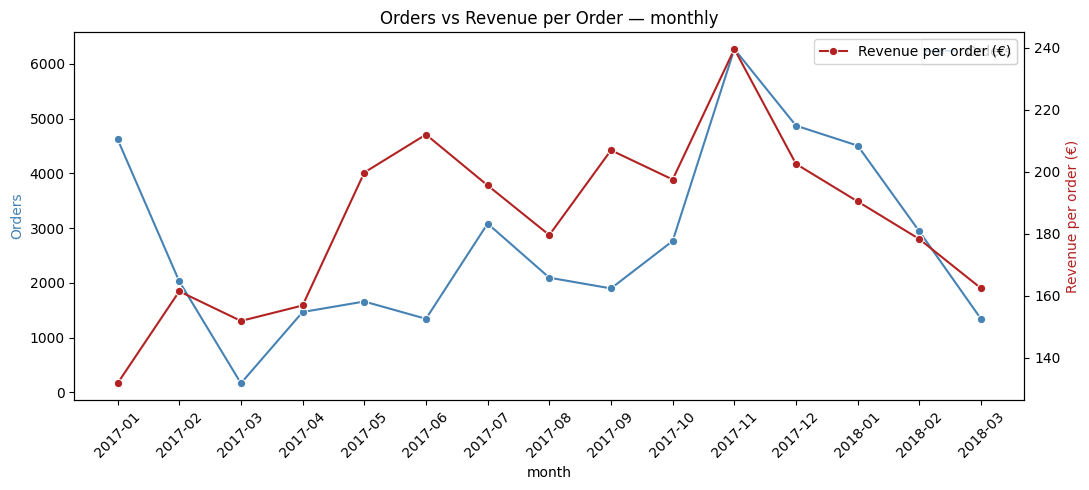

In [ ]:
# --- build discount fields at line-item level ---
df = orderlines_qq.merge(products_qq[['sku', 'price']], on='sku', how='left')
df['discount_amt'] = df['price'] - df['unit_price']
df['discount_pct'] = df['discount_amt'] / df['price'] * 100
df['is_discounted'] = df['discount_amt'] > 0.01
df['line_revenue'] = df['unit_price'] * df['product_quantity']
df['month'] = df['date'].dt.to_period('M')

monthly = df.groupby('month').agg(
    n_orders=('id_order', 'nunique'),
    revenue=('line_revenue', 'sum'),
    avg_discount_pct=('discount_pct', 'mean'),
    pct_lines_discounted=('is_discounted', 'mean')
)
monthly['revenue_per_order'] = monthly['revenue'] / monthly['n_orders']

# --- quick visual: orders vs revenue-per-order over time ---
fig, ax1 = plt.subplots(figsize=(11, 5))
sns.lineplot(x=monthly.index.astype(str), y=monthly['n_orders'], ax=ax1,
             marker='o', color='steelblue', label='Orders')
ax1.set_ylabel('Orders', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(x=monthly.index.astype(str), y=monthly['revenue_per_order'], ax=ax2,
             marker='o', color='firebrick', label='Revenue per order (€)')
ax2.set_ylabel('Revenue per order (€)', color='firebrick')

plt.title('Orders vs Revenue per Order — monthly')
fig.tight_layout()
plt.show()

- Orders (blue) and revenue per order (red) move together most of the year — both dip early in 2017, climb through mid-year, and peak sharply in Nov 2017 (Black Friday).
- After the November peak, both lines decline together through early 2018 — orders and revenue per order are falling in parallel, not diverging.
- The March 2017 dip is a data gap. It has consistenly less orders than Feb/April of the same year.

Key takeaway: this chart doesn't show "more orders, less revenue" — it shows both metrics rising and falling together, mainly driven by seasonality (the Nov-Dec peak). The board's "more orders, lower revenue" narrative likely comes from comparing Q4 (holiday peak) to Q1 (seasonal low), not from a real orders-vs-revenue tradeoff.

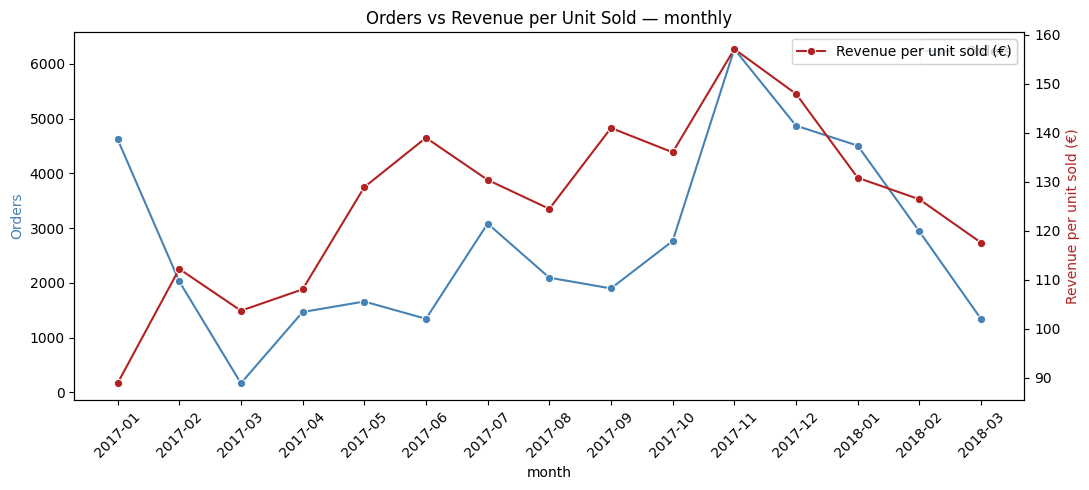

In [ ]:
# Revenue per unit sold = total revenue / total quantity sold
monthly['revenue_per_unit'] = monthly['revenue'] / df.groupby('month')['product_quantity'].sum()

fig, ax1 = plt.subplots(figsize=(11, 5))
sns.lineplot(x=monthly.index.astype(str), y=monthly['n_orders'], ax=ax1,
             marker='o', color='steelblue', label='Orders')
ax1.set_ylabel('Orders', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(x=monthly.index.astype(str), y=monthly['revenue_per_unit'], ax=ax2,
             marker='o', color='firebrick', label='Revenue per unit sold (€)')
ax2.set_ylabel('Revenue per unit sold (€)', color='firebrick')

plt.title('Orders vs Revenue per Unit Sold — monthly')
fig.tight_layout()
plt.show()

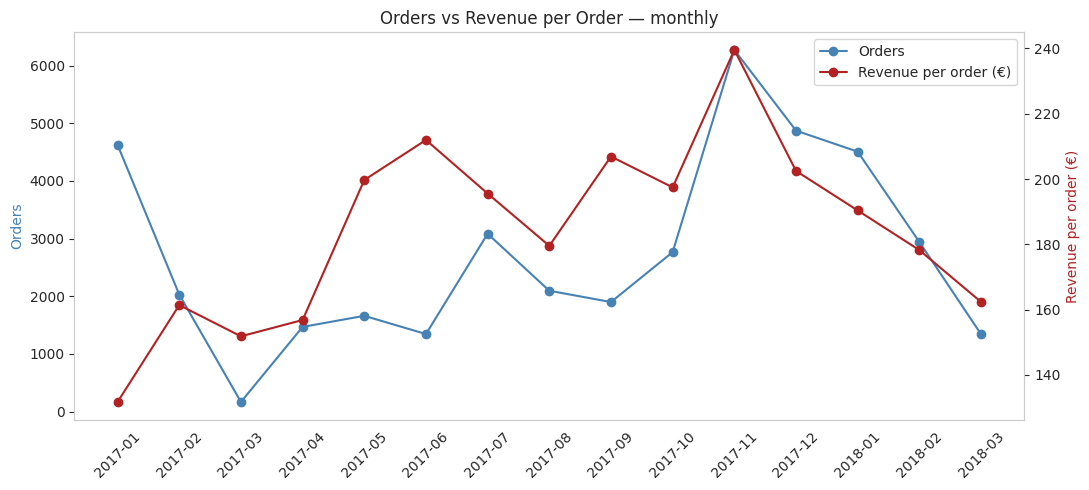

In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 5))

l1, = ax1.plot(monthly.index.astype(str), monthly['n_orders'], marker='o', color='steelblue', label='Orders')
ax1.set_ylabel('Orders', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(False)

ax2 = ax1.twinx()
l2, = ax2.plot(monthly.index.astype(str), monthly['revenue_per_order'], marker='o', color='firebrick', label='Revenue per order (€)')
ax2.set_ylabel('Revenue per order (€)', color='firebrick')
ax2.grid(False)

plt.title('Orders vs Revenue per Order — monthly')
ax1.legend(handles=[l1, l2], loc='upper right')
fig.tight_layout()
plt.show()

## Analysing categories

/tmp/ipykernel_2253/4161930785.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_categories, x='revenue_millions', y='category', palette='viridis')


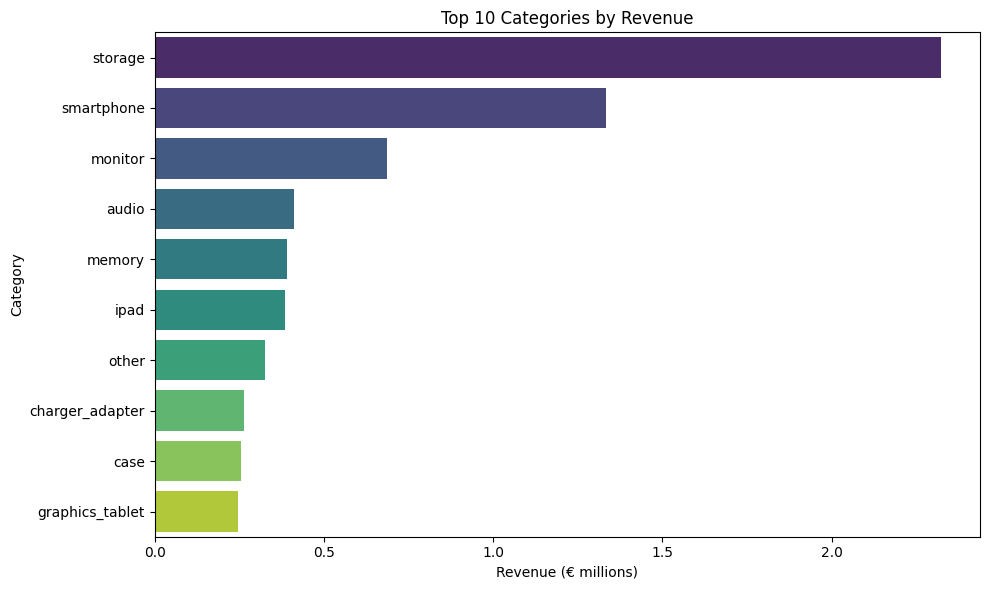

In [ ]:
# Top 10 categories by revenue
df_products = orderlines_qq.merge(products_qq[['sku', 'category']], on='sku', how='left')
df_products['line_revenue'] = df_products['unit_price'] * df_products['product_quantity']

top10_categories['revenue_millions'] = top10_categories['line_revenue'] / 1_000_000

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_categories, x='revenue_millions', y='category', palette='viridis')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue (€ millions)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2253/4199297699.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


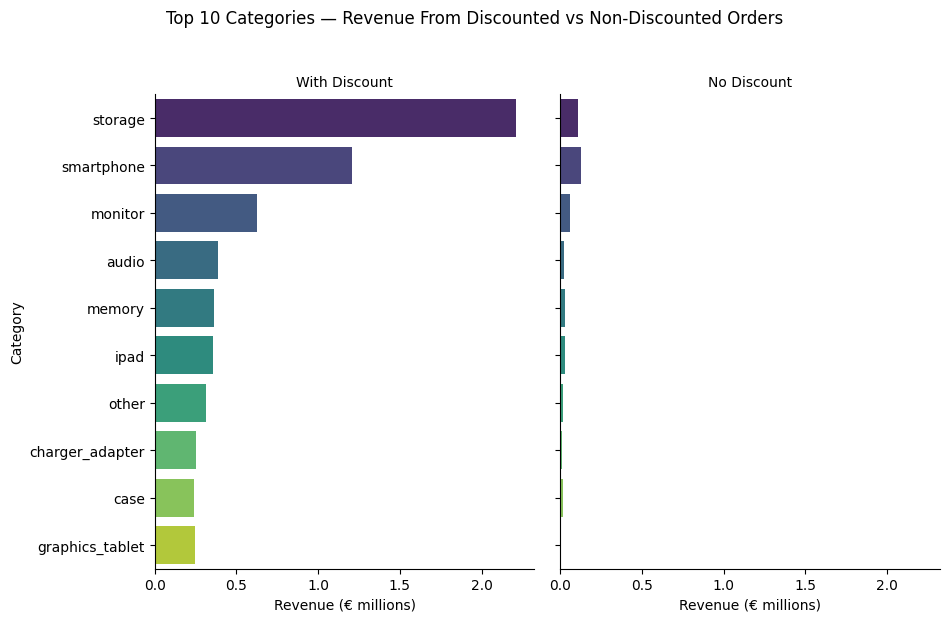

In [ ]:
# Revenue from actually discounted lines vs actually non-discounted lines
df_cat = orderlines_qq.merge(products_qq[['sku', 'category', 'price']], on='sku', how='left')
df_cat['line_revenue'] = df_cat['unit_price'] * df_cat['product_quantity']
df_cat['is_discounted'] = (df_cat['price'] - df_cat['unit_price']) > 0.01

top10 = (df_cat.groupby('category')['line_revenue']
         .sum().sort_values(ascending=False).head(10).index.tolist())

sub = df_cat[df_cat['category'].isin(top10)]

agg = sub.groupby(['category', 'is_discounted'])['line_revenue'].sum().reset_index()
agg['discount_status'] = agg['is_discounted'].map({True: 'With Discount', False: 'No Discount'})
agg['revenue_millions'] = agg['line_revenue'] / 1_000_000

g = sns.catplot(
    data=agg, x='revenue_millions', y='category',
    col='discount_status', kind='bar', order=top10,
    col_order=['With Discount', 'No Discount'],
    palette='viridis', height=6, aspect=0.8, sharex=True
)
g.set_axis_labels('Revenue (€ millions)', 'Category')
g.set_titles('{col_name}')
g.fig.suptitle('Top 10 Categories — Revenue From Discounted vs Non-Discounted Orders', y=1.03)
plt.tight_layout()
plt.show()

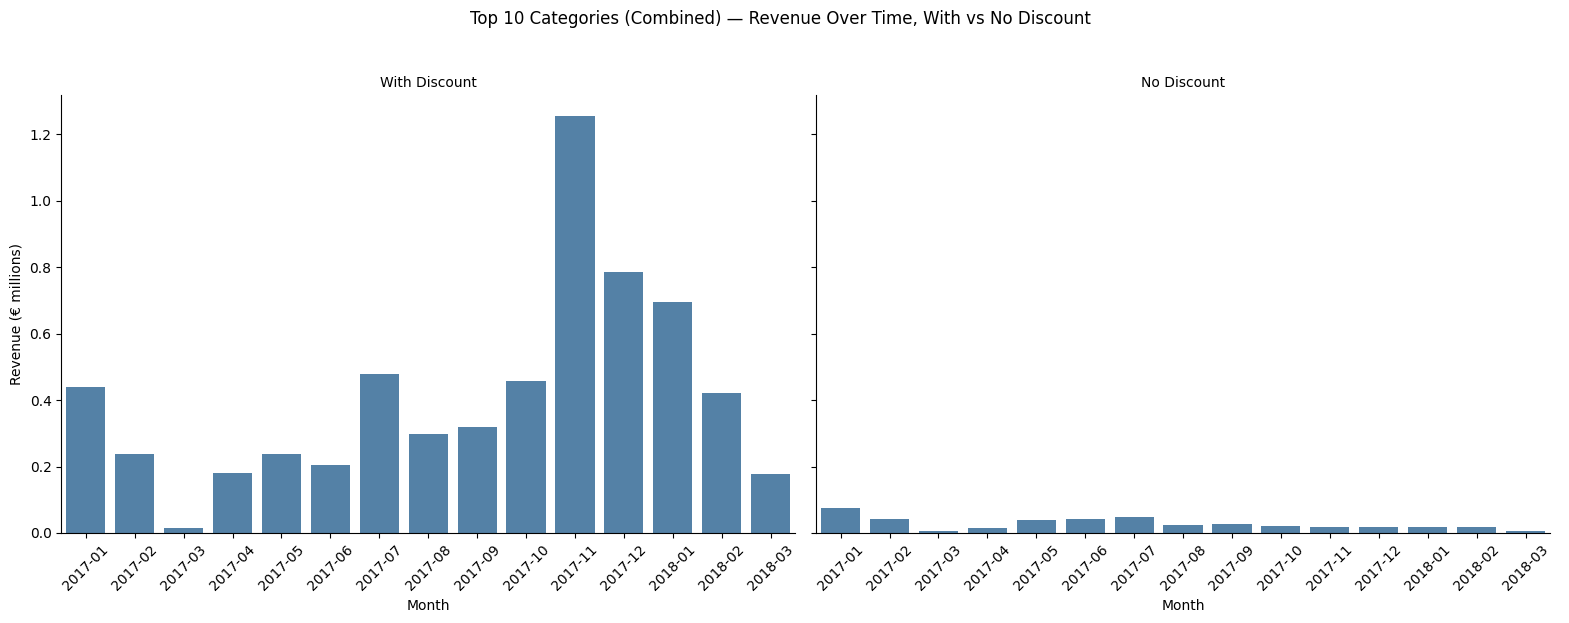

In [ ]:
# Aggregate top10 categories into a single group, revenue over time, split real discount vs no discount
df_cat = orderlines_qq.merge(products_qq[['sku', 'category', 'price']], on='sku', how='left')
df_cat['line_revenue'] = df_cat['unit_price'] * df_cat['product_quantity']
df_cat['is_discounted'] = (df_cat['price'] - df_cat['unit_price']) > 0.01
df_cat['month'] = df_cat['date'].dt.to_period('M').astype(str)

top10 = (df_cat.groupby('category')['line_revenue']
         .sum().sort_values(ascending=False).head(10).index.tolist())

sub = df_cat[df_cat['category'].isin(top10)]

agg = sub.groupby(['month', 'is_discounted'])['line_revenue'].sum().reset_index()
agg['discount_status'] = agg['is_discounted'].map({True: 'With Discount', False: 'No Discount'})
agg['revenue_millions'] = agg['line_revenue'] / 1_000_000

g = sns.catplot(
    data=agg, x='month', y='revenue_millions',
    col='discount_status', kind='bar',
    col_order=['With Discount', 'No Discount'],
    color='steelblue', height=6, aspect=1.3, sharex=True, sharey=True
)
g.set_axis_labels('Month', 'Revenue (€ millions)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
g.fig.suptitle('Top 10 Categories (Combined) — Revenue Over Time, With vs No Discount', y=1.03)
plt.tight_layout()
plt.show()

## Discounts

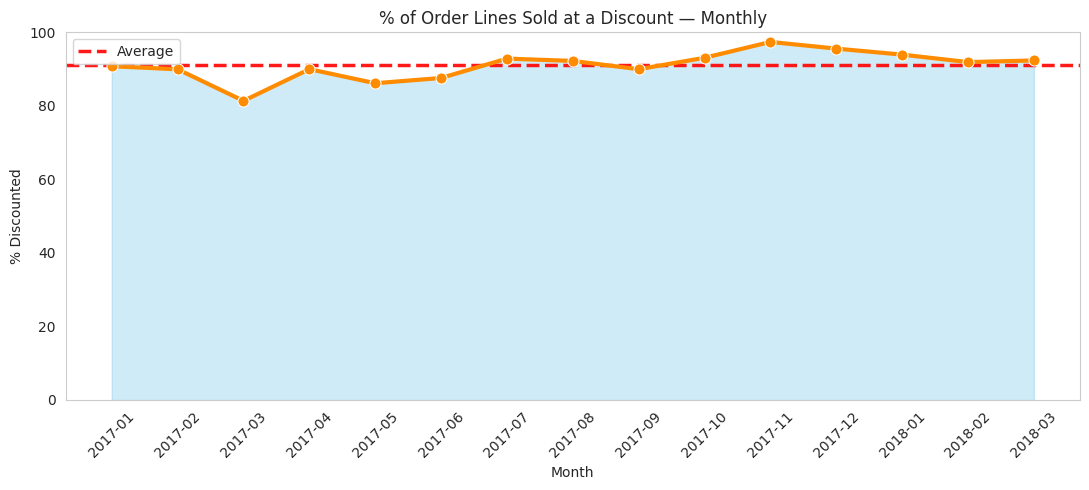

In [ ]:
df_prod = orderlines_qq.merge(products_qq[['sku', 'category', 'price']], on='sku', how='left')
df_prod['discount_pct'] = (df_prod['price'] - df_prod['unit_price']) / df_prod['price'] * 100
df_prod['is_discounted'] = df_prod['discount_pct'] > 0.01
df_prod['month'] = df_prod['date'].dt.to_period('M').astype(str)

pct_time = df_prod.groupby('month')['is_discounted'].mean().mul(100).reset_index()
pct_time.columns = ['month', 'pct_discounted']

plt.figure(figsize=(11, 5))

plt.fill_between(pct_time['month'], pct_time['pct_discounted'], color='skyblue', alpha=0.4, zorder=1)
sns.lineplot(data=pct_time, x='month', y='pct_discounted', marker='o',
             color='darkorange', linewidth=3, markersize=8, zorder=3)
plt.axhline(pct_time['pct_discounted'].mean(), linestyle='--', color='red', linewidth=2.5, alpha=0.9,
            label='Average', zorder=2)

plt.title('% of Order Lines Sold at a Discount — Monthly')
plt.ylabel('% Discounted')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

Between 81% and 97% of order lines were sold at a discount every single month, with no month below 80%. This confirms discounting isn't tied to specific promotions, it's the default way products are sold at Eniac, consistently across the entire period.

/tmp/ipykernel_2253/3491005102.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sku_df, x='status', y='count', palette=['steelblue', 'lightgray'])


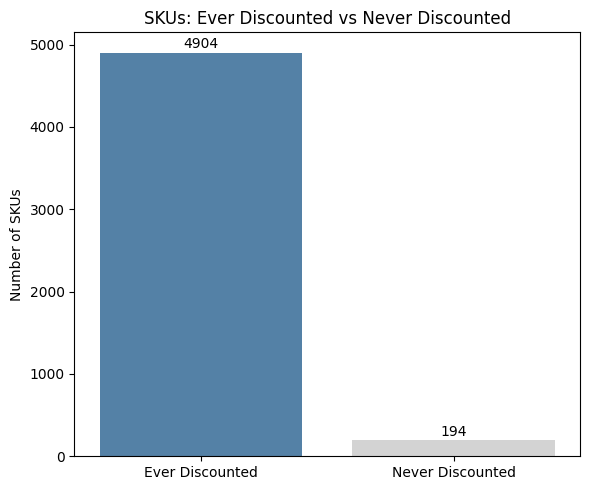

In [ ]:
sku_status = df_prod.groupby('sku')['is_discounted'].any()
sku_counts = sku_status.value_counts().rename({True: 'Ever Discounted', False: 'Never Discounted'})
sku_df = sku_counts.reset_index()
sku_df.columns = ['status', 'count']

plt.figure(figsize=(6, 5))
sns.barplot(data=sku_df, x='status', y='count', palette=['steelblue', 'lightgray'])
plt.title('SKUs: Ever Discounted vs Never Discounted')
plt.ylabel('Number of SKUs')
plt.xlabel('')
for i, v in enumerate(sku_df['count']):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

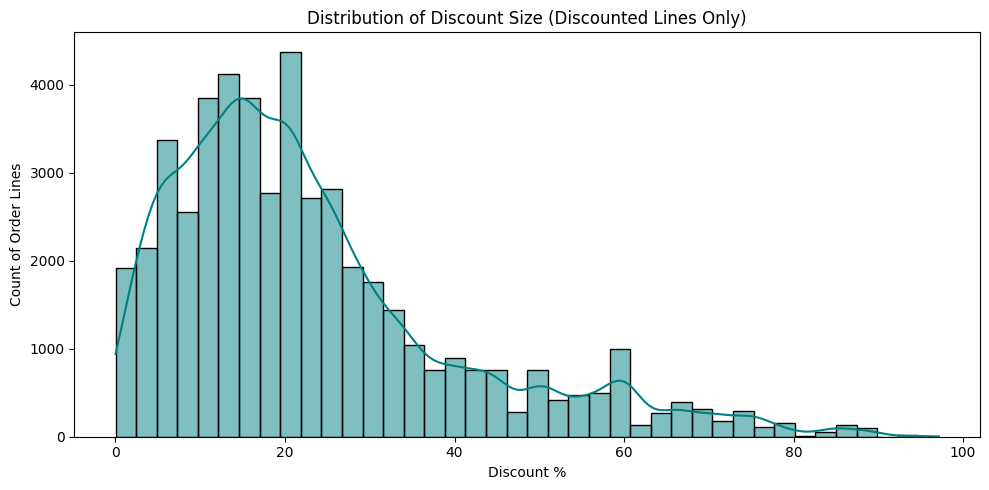

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_prod[df_prod['is_discounted']]['discount_pct'], bins=40, kde=True, color='teal')
plt.title('Distribution of Discount Size (Discounted Lines Only)')
plt.xlabel('Discount %')
plt.ylabel('Count of Order Lines')
plt.tight_layout()
plt.show()

The line is a KDE, a smoothed version of the histogram that makes the distribution's shape easier to read past the noise of individual bars.
Using it, we can see discounts mostly fall between 5% and 30%, peaking around 15-20% — moderate, not aggressive. The KDE also makes the secondary bump near 60% clearer despite the jagged bars there, plus a long thin tail up to nearly 100%, meaning a minority of items get very steep discounts. Overall this looks like broad, systematic discounting rather than occasional deep clearance sales.

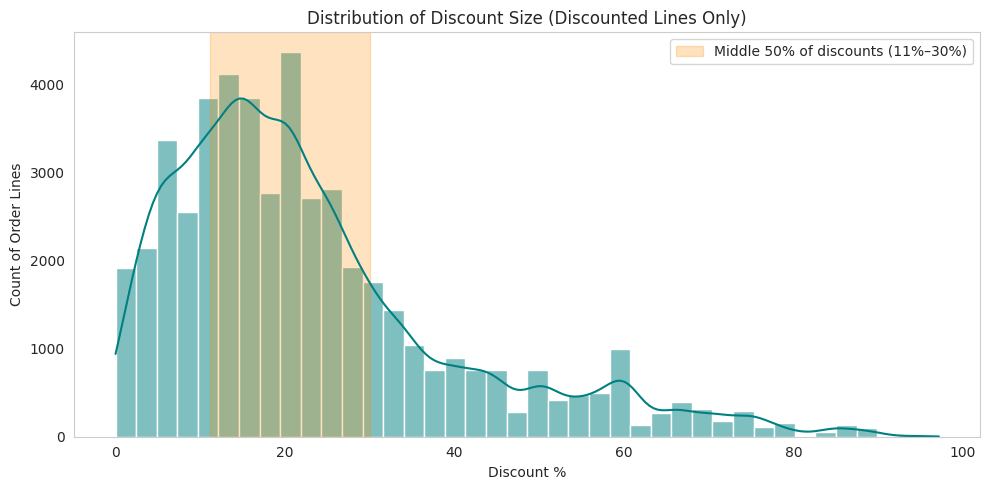

In [ ]:
df_prod = orderlines_qq.merge(products_qq[['sku', 'price']], on='sku', how='left')
df_prod['discount_pct'] = (df_prod['price'] - df_prod['unit_price']) / df_prod['price'] * 100
df_prod['is_discounted'] = df_prod['discount_pct'] > 0.01

q25 = df_prod[df_prod['is_discounted']]['discount_pct'].quantile(0.25)
q75 = df_prod[df_prod['is_discounted']]['discount_pct'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_prod[df_prod['is_discounted']]['discount_pct'], bins=40, kde=True, color='teal', ax=ax)
ax.axvspan(q25, q75, color='darkorange', alpha=0.25, label=f'Middle 50% of discounts ({q25:.0f}%–{q75:.0f}%)')

ax.set_title('Distribution of Discount Size (Discounted Lines Only)')
ax.set_xlabel('Discount %')
ax.set_ylabel('Count of Order Lines')
ax.grid(False)
ax.legend()
plt.tight_layout()
plt.show()

Discounts mostly fall between 11% and 30% (the shaded orange band), covering about half of all discounted sales. Very few sales have discounts above 60% or below 5%, so most discounting stays in a moderate, predictable range rather than swinging to extremes.

## Sales during special seasons

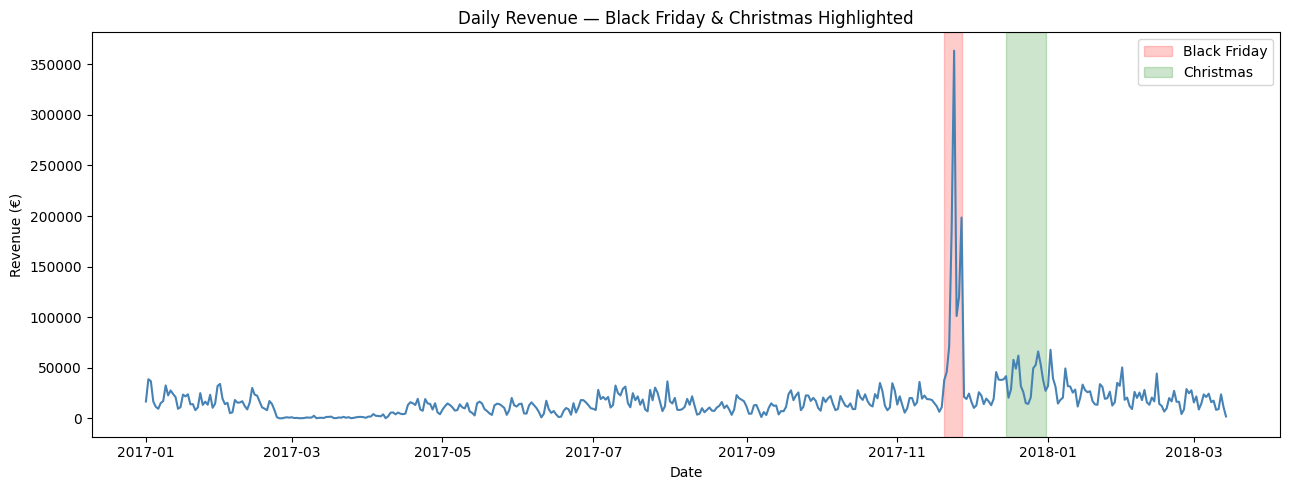

In [ ]:
df_prod = orderlines_qq.merge(products_qq[['sku', 'category', 'price']], on='sku', how='left')
df_prod['line_revenue'] = df_prod['unit_price'] * df_prod['product_quantity']
df_prod['discount_pct'] = (df_prod['price'] - df_prod['unit_price']) / df_prod['price'] * 100
df_prod['is_discounted'] = df_prod['discount_pct'] > 0.01

def flag_period(d):
    if d.month == 11 and 20 <= d.day <= 27:
        return 'Black Friday'
    if d.month == 12 and 15 <= d.day <= 31:
        return 'Christmas'
    return 'Regular'

df_prod['period'] = df_prod['date'].apply(flag_period)

daily_rev = df_prod.groupby(df_prod['date'].dt.date)['line_revenue'].sum().reset_index()
daily_rev.columns = ['date', 'revenue']
daily_rev['date'] = pd.to_datetime(daily_rev['date'])

plt.figure(figsize=(13, 5))
sns.lineplot(data=daily_rev, x='date', y='revenue', color='steelblue')
plt.axvspan(pd.Timestamp('2017-11-20'), pd.Timestamp('2017-11-27'), color='red', alpha=0.2, label='Black Friday')
plt.axvspan(pd.Timestamp('2017-12-15'), pd.Timestamp('2017-12-31'), color='green', alpha=0.2, label='Christmas')
plt.title('Daily Revenue — Black Friday & Christmas Highlighted')
plt.ylabel('Revenue (€)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

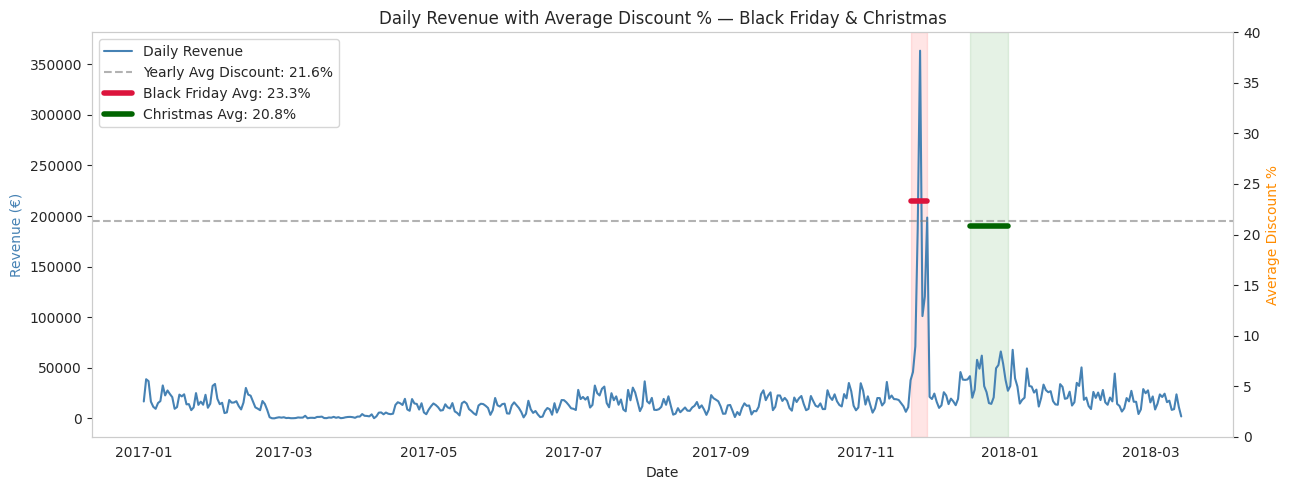

In [ ]:
fig, ax1 = plt.subplots(figsize=(13, 5))

l1, = ax1.plot(daily_rev['date'], daily_rev['revenue'], color='steelblue', label='Daily Revenue')
ax1.set_ylabel('Revenue (€)', color='steelblue')
ax1.set_xlabel('Date')
ax1.grid(False)

ax2 = ax1.twinx()

l2 = ax2.axhline(overall_avg, linestyle='--', color='gray', alpha=0.6,
            label='Yearly Avg Discount: 21.6%')

l3, = ax2.plot([pd.Timestamp('2017-11-20'), pd.Timestamp('2017-11-27')], [bf_avg, bf_avg],
               color='crimson', linewidth=4, solid_capstyle='round', label=f'Black Friday Avg: {bf_avg:.1f}%')
l4, = ax2.plot([pd.Timestamp('2017-12-15'), pd.Timestamp('2017-12-31')], [xmas_avg, xmas_avg],
               color='darkgreen', linewidth=4, solid_capstyle='round', label=f'Christmas Avg: {xmas_avg:.1f}%')

ax2.set_ylabel('Average Discount %', color='darkorange')
ax2.set_ylim(0, 40)
ax2.grid(False)

ax1.axvspan(pd.Timestamp('2017-11-20'), pd.Timestamp('2017-11-27'), color='red', alpha=0.1)
ax1.axvspan(pd.Timestamp('2017-12-15'), pd.Timestamp('2017-12-31'), color='green', alpha=0.1)

ax1.set_title('Daily Revenue with Average Discount % — Black Friday & Christmas')
ax1.legend(handles=[l1, l2, l3, l4], loc='upper left')
plt.tight_layout()
plt.show()

Black Friday produces a sharp, extreme spike (over €360K in a single day, roughly 10x baseline), while Christmas shows a more moderate, sustained lift with several elevated days rather than one huge peak. Both are clearly special events, but Black Friday is a short, intense burst compared to Christmas's broader bump.


/tmp/ipykernel_2253/956685383.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='period', y='revenue_per_day', palette=['black', 'crimson', 'lightgray'],


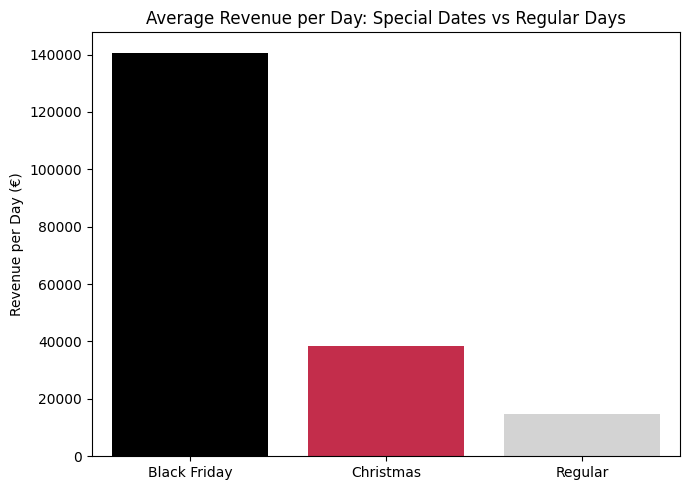

In [ ]:
summary = df_prod.groupby('period').agg(
    n_orders=('id_order', 'nunique'),
    revenue=('line_revenue', 'sum')
)
days = df_prod.groupby('period')['date'].apply(lambda x: x.dt.date.nunique())
summary['revenue_per_day'] = summary['revenue'] / days
summary = summary.reset_index().sort_values('revenue_per_day', ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=summary, x='period', y='revenue_per_day', palette=['black', 'crimson', 'lightgray'],
            order=['Black Friday', 'Christmas', 'Regular'])
plt.title('Average Revenue per Day: Special Dates vs Regular Days')
plt.ylabel('Revenue per Day (€)')
plt.xlabel('')
plt.tight_layout()
plt.show()

Black Friday averages roughly 9.6x the revenue of a regular day, while Christmas is about 2.6x. Both confirm special dates drive substantially higher daily revenue, with Black Friday being by far the stronger event.

## Price disperson per category

/tmp/ipykernel_2253/189197808.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_prod[sub_prod['category'].isin(high_price_cats)], x='price', y='category',
/tmp/ipykernel_2253/189197808.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_prod[sub_prod['category'].isin(low_price_cats)], x='price', y='category',


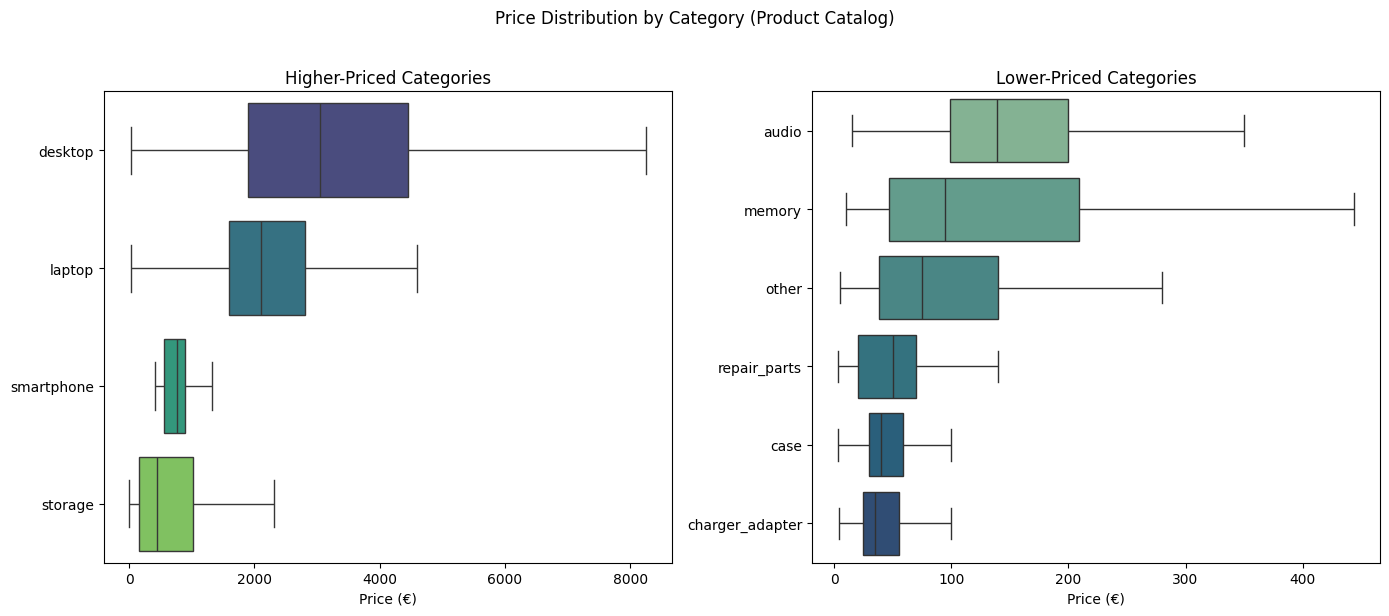

In [ ]:
top_cats_by_count = products_qq['category'].value_counts().head(10).index.tolist()
sub_prod = products_qq[products_qq['category'].isin(top_cats_by_count)]

high_price_cats = ['desktop', 'laptop', 'smartphone', 'storage']
low_price_cats = [c for c in top_cats_by_count if c not in high_price_cats]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order_high = sub_prod[sub_prod['category'].isin(high_price_cats)].groupby('category')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=sub_prod[sub_prod['category'].isin(high_price_cats)], x='price', y='category',
            order=order_high, palette='viridis', ax=axes[0], showfliers=False)
axes[0].set_title('Higher-Priced Categories')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('')

order_low = sub_prod[sub_prod['category'].isin(low_price_cats)].groupby('category')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=sub_prod[sub_prod['category'].isin(low_price_cats)], x='price', y='category',
            order=order_low, palette='crest', ax=axes[1], showfliers=False)
axes[1].set_title('Lower-Priced Categories')
axes[1].set_xlabel('Price (€)')
axes[1].set_ylabel('')

fig.suptitle('Price Distribution by Category (Product Catalog)', y=1.02)
plt.tight_layout()
plt.show()

Higher priced categories: desktop has the widest range and the highest median (around €3,000), with prices reaching up to about €8,000. laptop follows with a median around €2,100. smartphone and storage are more compact, with much lower medians (around €800 and €500) and tighter ranges, though storage has somewhat more spread on the upper end.
Lower priced categories: audio and memory have the highest medians in this group (around €140 and €90) and wider ranges, while case and charger_adapter are the cheapest and most compact, with medians around €40 to €50 and little variation.
Together this confirms a clear segmentation in the catalog: three or four categories (desktop, laptop, smartphone) sit in the premium segment, while the rest are lower priced accessories where the business competes more on volume than margin.

## AVG % per category

/tmp/ipykernel_2253/1069888785.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=left_summary, x='discount_pct', y='category', palette='rocket', ax=axes[0])
/tmp/ipykernel_2253/1069888785.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=right_summary, x='discount_pct', y='category', palette='rocket', ax=axes[1])


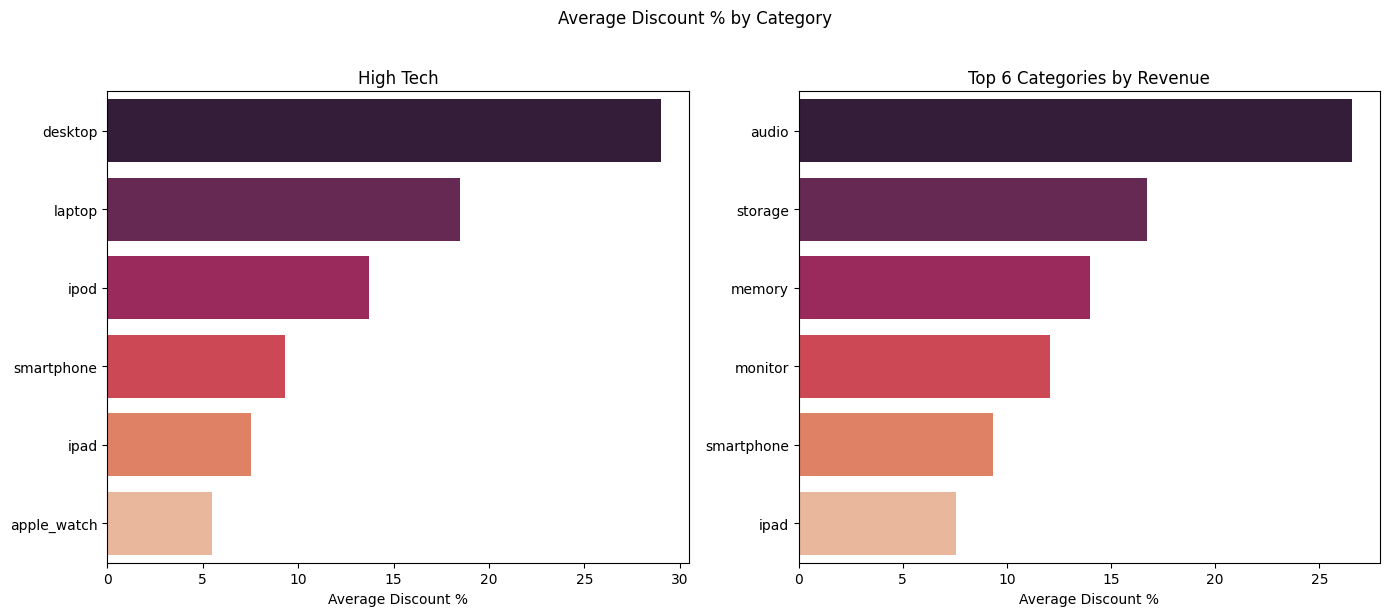

In [ ]:
df_prod = orderlines_qq.merge(products_qq[['sku', 'category', 'price']], on='sku', how='left')
df_prod['line_revenue'] = df_prod['unit_price'] * df_prod['product_quantity']
df_prod['discount_pct'] = (df_prod['price'] - df_prod['unit_price']) / df_prod['price'] * 100

device_cats = ['apple_watch', 'desktop', 'laptop', 'ipad', 'smartphone', 'ipod']
top6_revenue = (df_prod.groupby('category')['line_revenue']
                .sum().sort_values(ascending=False).head(6).index.tolist())

left_summary = (df_prod[df_prod['category'].isin(device_cats)]
                .groupby('category')['discount_pct'].mean()
                .sort_values(ascending=False).reset_index())

right_summary = (df_prod[df_prod['category'].isin(top6_revenue)]
                  .groupby('category')['discount_pct'].mean()
                  .sort_values(ascending=False).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=left_summary, x='discount_pct', y='category', palette='rocket', ax=axes[0])
axes[0].set_title('High Tech')
axes[0].set_xlabel('Average Discount %')
axes[0].set_ylabel('')

sns.barplot(data=right_summary, x='discount_pct', y='category', palette='rocket', ax=axes[1])
axes[1].set_title('Top 6 Categories by Revenue')
axes[1].set_xlabel('Average Discount %')
axes[1].set_ylabel('')

fig.suptitle('Average Discount % by Category', y=1.02)
plt.tight_layout()
plt.show()

## Revenue vs Discount

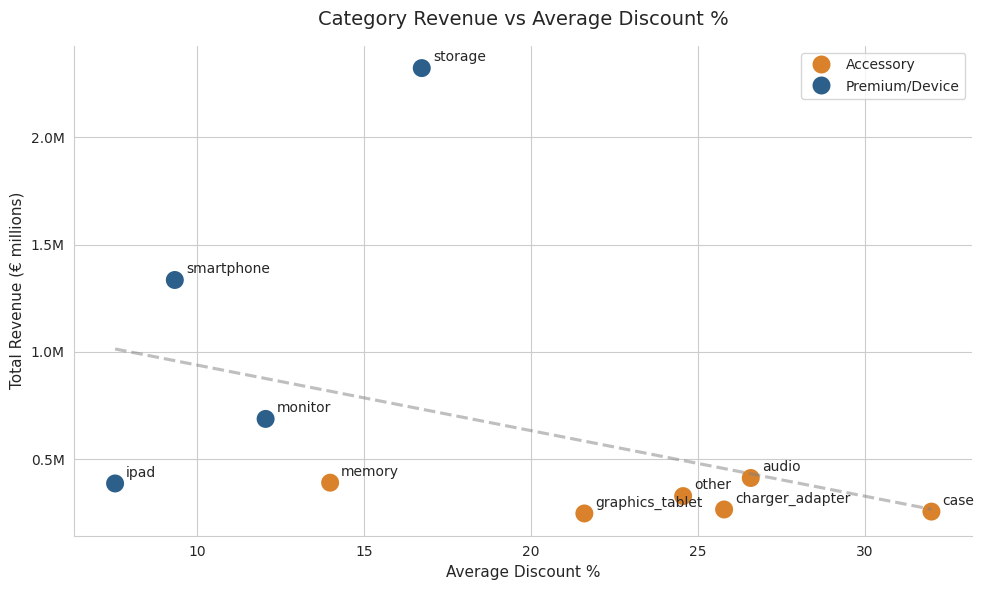

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

# color by device type vs accessory, for a clearer visual story
premium_cats = ['storage', 'smartphone', 'monitor', 'ipad']
cat_summary['segment'] = cat_summary['category'].apply(lambda c: 'Premium/Device' if c in premium_cats else 'Accessory')

palette = {'Premium/Device': '#2C5F8A', 'Accessory': '#D9822B'}

ax = sns.scatterplot(
    data=cat_summary, x='avg_discount_pct', y='total_revenue',
    hue='segment', palette=palette, s=200, edgecolor='white', linewidth=1.2
)

# add a light trendline to show the overall relationship
sns.regplot(
    data=cat_summary, x='avg_discount_pct', y='total_revenue',
    scatter=False, ci=None, color='gray', line_kws={'linestyle': '--', 'alpha': 0.5}
)

# offset labels so they don't collide with points
for _, row in cat_summary.iterrows():
    ax.annotate(row['category'], (row['avg_discount_pct'], row['total_revenue']),
                xytext=(8, 5), textcoords='offset points', fontsize=10)

ax.set_title('Category Revenue vs Average Discount %', fontsize=14, pad=15)
ax.set_xlabel('Average Discount %', fontsize=11)
ax.set_ylabel('Total Revenue (€ millions)', fontsize=11)
ax.yaxis.set_major_formatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.legend(title='', loc='upper right', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

There's a clear negative trend: higher average discount tends to mean lower total category revenue, confirmed visually by the dashed trendline. One category breaks the pattern though: storage has the highest revenue (€2.3M) with only a moderate discount (~17%), suggesting sales volume there more than compensates for the discount.

Premium categories (smartphone, monitor, ipad, blue) cluster in the low-discount zone (7-17%) with medium-to-high revenue, while accessories (case, charger_adapter, audio, orange) sit in the high-discount zone (22-32%) but consistently low revenue — none of them compensate for the steep discount with enough volume to approach premium-category revenue.

For the board: this suggests aggressive discounting on accessories isn't driving enough volume to justify itself in revenue, while the categories that discount the least (storage, smartphone) are the ones contributing the most — supporting the case for positioning around quality rather than low price.

## Orderlines per day

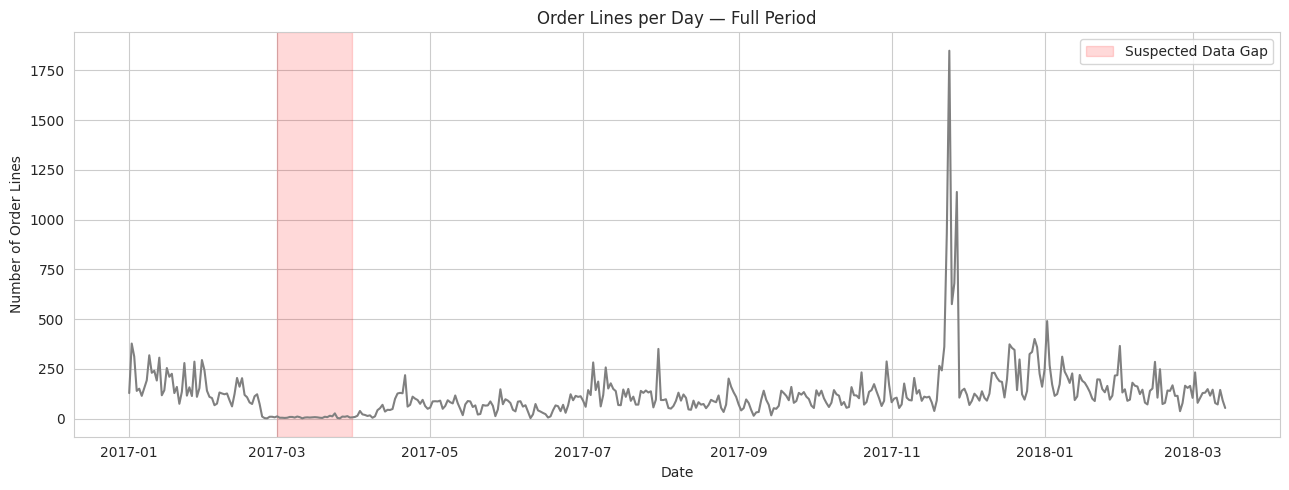

In [ ]:
daily_lines = orderlines_qq.groupby(orderlines_qq['date'].dt.date).size().reset_index()
daily_lines.columns = ['date', 'n_lines']
daily_lines['date'] = pd.to_datetime(daily_lines['date'])

plt.figure(figsize=(13, 5))
sns.lineplot(data=daily_lines, x='date', y='n_lines', color='gray')
plt.axvspan(pd.Timestamp('2017-03-01'), pd.Timestamp('2017-03-31'), color='red', alpha=0.15, label='Suspected Data Gap')
plt.title('Order Lines per Day — Full Period')
plt.ylabel('Number of Order Lines')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

## Revenue by product condition

/tmp/ipykernel_2253/2948052768.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(condition_summary['label'])


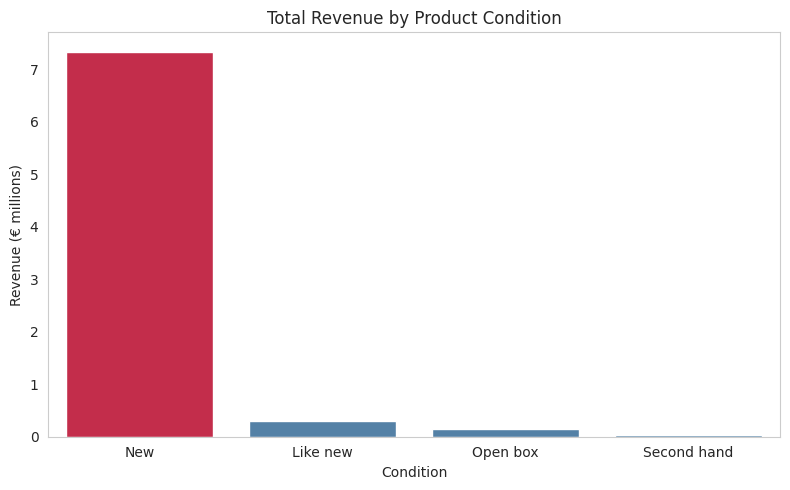

In [ ]:
df_prod = orderlines_qq.merge(products_qq[['sku', 'condition', 'price']], on='sku', how='left')
df_prod['line_revenue'] = df_prod['unit_price'] * df_prod['product_quantity']

condition_summary = (df_prod.groupby('condition')['line_revenue']
                      .sum().sort_values(ascending=False).reset_index())
condition_summary['revenue_millions'] = condition_summary['line_revenue'] / 1_000_000

condition_summary['label'] = condition_summary['condition'].str.replace('_', ' ').str.capitalize()

palette = {c: ('crimson' if c == 'new' else 'steelblue') for c in condition_summary['condition']}

plt.figure(figsize=(8, 5))
sns.barplot(data=condition_summary, x='condition', y='revenue_millions',
            hue='condition', palette=palette, legend=False)
plt.gca().set_xticklabels(condition_summary['label'])
plt.title('Total Revenue by Product Condition')
plt.ylabel('Revenue (€ millions)')
plt.xlabel('Condition')
plt.grid(False)
plt.tight_layout()
plt.show()

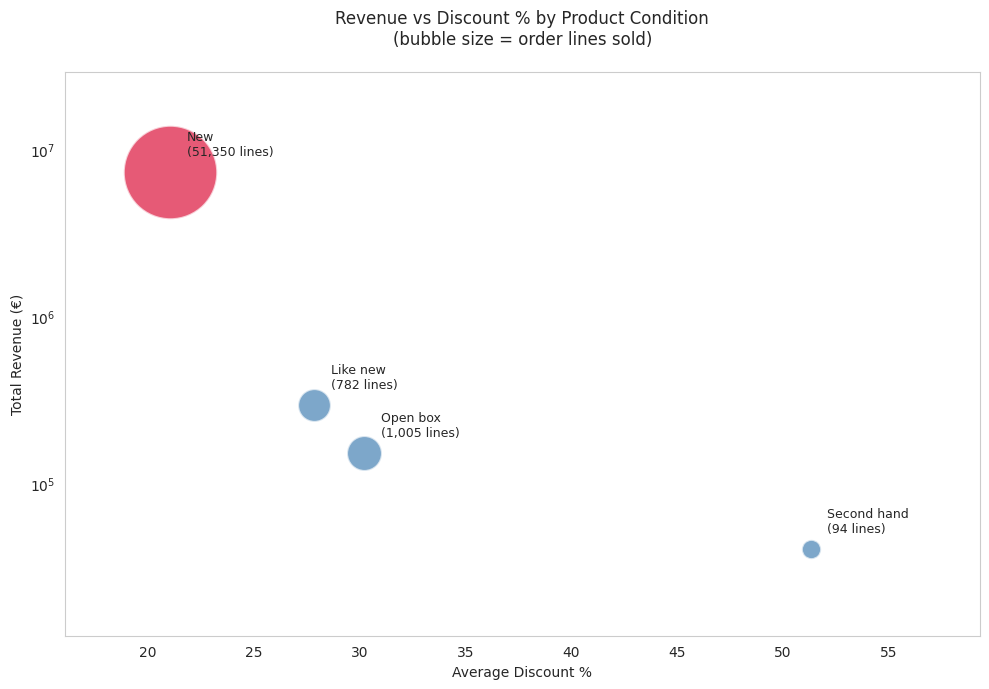

In [ ]:
condition_summary['bubble_size'] = condition_summary['n_lines'] ** 0.5 * 20  # sqrt scaling keeps sizes proportional but readable

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in condition_summary.iterrows():
    ax.scatter(row['avg_discount_pct'], row['total_revenue'],
               s=row['bubble_size'], color=palette[row['condition']], alpha=0.7, edgecolor='white', linewidth=1.5)
    ax.annotate(f"{row['label']}\n({row['n_lines']:,} lines)",
                (row['avg_discount_pct'], row['total_revenue']),
                xytext=(12, 12), textcoords='offset points', fontsize=9)

ax.set_title('Revenue vs Discount % by Product Condition\n(bubble size = order lines sold)', pad=20)
ax.set_xlabel('Average Discount %')
ax.set_ylabel('Total Revenue (€)')
ax.set_yscale('log')
ax.set_ylim(condition_summary['total_revenue'].min() * 0.3, condition_summary['total_revenue'].max() * 4)
ax.set_xlim(condition_summary['avg_discount_pct'].min() - 5, condition_summary['avg_discount_pct'].max() + 8)
ax.grid(False)
plt.tight_layout()
plt.show()